In [10]:
import pandas as pd
import numpy as np

In [11]:
df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [13]:
grouped = df.groupby("Pclass")["Fare"]

summary_stats = grouped.agg(['mean', 'median', 'min', 'max', 'std'])

print(summary_stats)

             mean   median  min       max        std
Pclass                                              
1       84.154687  60.2875  0.0  512.3292  78.380373
2       20.662183  14.2500  0.0   73.5000  13.417399
3       13.675550   8.0500  0.0   69.5500  11.778142


In [14]:
summary_dict = {}

for pclass, data in grouped:
    stats_list = [
        data.mean(),
        data.median(),
        data.min(),
        data.max(),
        data.std()
    ]
    summary_dict[pclass] = stats_list

summary_dict

{1: [84.15468749999992, 60.287499999999994, 0.0, 512.3292, 78.38037264672884],
 2: [20.66218315217391, 14.25, 0.0, 73.5, 13.417398756149332],
 3: [13.675550101832997, 8.05, 0.0, 69.55, 11.7781417043873]}

In [15]:
{
  1: [84.15, 60.28, 0.0, 512.33, 78.38],
  2: [20.66, 14.25, 0.0, 73.50, 13.42],
  3: [13.67, 8.05, 0.0, 69.55, 11.78]
}

{1: [84.15, 60.28, 0.0, 512.33, 78.38],
 2: [20.66, 14.25, 0.0, 73.5, 13.42],
 3: [13.67, 8.05, 0.0, 69.55, 11.78]}

In [16]:
age_group = df.groupby("Sex")["Age"]
age_summary = age_group.agg(['mean','median','min','max','std'])
print(age_summary)

             mean  median   min   max        std
Sex                                             
female  27.915709    27.0  0.75  63.0  14.110146
male    30.726645    29.0  0.42  80.0  14.678201


In [17]:
df = pd.read_csv("Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [18]:
df['Species'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [19]:
df = df.drop(columns=['Id'])

In [20]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [21]:
species_groups = df.groupby("Species")

for name, group in species_groups:
    print("\nSpecies:", name)
    
    print("\nMean:\n", group.mean())
    
    print("\nStandard Deviation:\n", group.std())
    
    print("\nPercentiles (25%, 50%, 75%):\n")
    print(group.quantile([0.25, 0.50, 0.75]))


Species: Iris-setosa

Mean:
 SepalLengthCm    5.006
SepalWidthCm     3.418
PetalLengthCm    1.464
PetalWidthCm     0.244
dtype: float64

Standard Deviation:
 SepalLengthCm    0.352490
SepalWidthCm     0.381024
PetalLengthCm    0.173511
PetalWidthCm     0.107210
dtype: float64

Percentiles (25%, 50%, 75%):

      SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0.25            4.8         3.125          1.400           0.2
0.50            5.0         3.400          1.500           0.2
0.75            5.2         3.675          1.575           0.3

Species: Iris-versicolor

Mean:
 SepalLengthCm    5.936
SepalWidthCm     2.770
PetalLengthCm    4.260
PetalWidthCm     1.326
dtype: float64

Standard Deviation:
 SepalLengthCm    0.516171
SepalWidthCm     0.313798
PetalLengthCm    0.469911
PetalWidthCm     0.197753
dtype: float64

Percentiles (25%, 50%, 75%):

      SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0.25            5.6         2.525           4.00           1.2


/tmp/ipykernel_9053/3801971680.py:6: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  print("\nMean:\n", group.mean())
/tmp/ipykernel_9053/3801971680.py:8: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  print("\nStandard Deviation:\n", group.std())
/tmp/ipykernel_9053/3801971680.py:6: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  print("\nMean:\n", group.mean())
/tmp/ipykernel_9053/3801971680.py:8: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None

In [22]:
for name, group in df.groupby("Species"):
    print("\n==============================")
    print("Species:", name)
    print("==============================")
    print(group.describe())


Species: Iris-setosa
       SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count       50.00000     50.000000      50.000000      50.00000
mean         5.00600      3.418000       1.464000       0.24400
std          0.35249      0.381024       0.173511       0.10721
min          4.30000      2.300000       1.000000       0.10000
25%          4.80000      3.125000       1.400000       0.20000
50%          5.00000      3.400000       1.500000       0.20000
75%          5.20000      3.675000       1.575000       0.30000
max          5.80000      4.400000       1.900000       0.60000

Species: Iris-versicolor
       SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count      50.000000     50.000000      50.000000     50.000000
mean        5.936000      2.770000       4.260000      1.326000
std         0.516171      0.313798       0.469911      0.197753
min         4.900000      2.000000       3.000000      1.000000
25%         5.600000      2.525000       4.000000      1

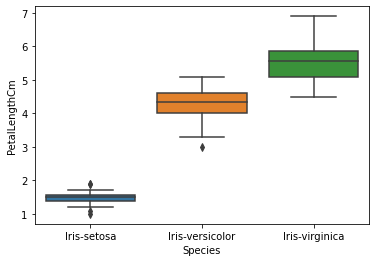

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="Species", y="PetalLengthCm", data=df)
plt.show()